## Setup and Configuration

This section initializes all the necessary components for reproducible deep learning:

- **Seed fixing**: Sets random seeds across Python, NumPy, and PyTorch for reproducibility
- **Device setup**: Automatically detects and uses CUDA GPU if available
- **Library imports**: Loads essential libraries including PyTorch, torchvision, OpenCV, scikit-learn, and visualization tools
- **Directory creation**: Creates the `models/` folder for saving trained weights

In [ ]:
SEED = 42

import os
import warnings
import random
import numpy as np
import torch

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"🌱 Seed fissato a: {seed}")

seed_everything(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

from torch import nn
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision.transforms import v2 as transforms
import torch.optim as optim
from sklearn.utils.class_weight import compute_class_weight

import cv2
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import pandas as pd
from pathlib import Path
from tqdm import tqdm

sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

os.makedirs('models', exist_ok=True)

print("✅ Setup completato")

🌱 Seed fissato a: 42
PyTorch version: 2.6.0+cu124
Device: cuda
✅ Setup completato


## Lion Optimizer

Implementation of the **Lion (EvoLved Sign Momentum)** optimizer.

### Key Features:
- **Memory efficient**: Only tracks one momentum buffer (vs. two for Adam)
- **Sign-based updates**: Uses the sign of the momentum for updates, leading to uniform step sizes
- **Effective for vision tasks**: Often outperforms AdamW on image classification
- **Lower learning rate**: Typically requires 3-10x smaller learning rate than Adam

In [ ]:
from torch.optim.optimizer import Optimizer

class Lion(Optimizer):
    def __init__(self, params, lr=1e-4, betas=(0.9, 0.99), weight_decay=0.0):
        if not 0.0 <= lr:
            raise ValueError(f'Invalid learning rate: {lr}')
        if not 0.0 <= betas[0] < 1.0:
            raise ValueError(f'Invalid beta parameter at index 0: {betas[0]}')
        if not 0.0 <= betas[1] < 1.0:
            raise ValueError(f'Invalid beta parameter at index 1: {betas[1]}')
        defaults = dict(lr=lr, betas=betas, weight_decay=weight_decay)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad
                lr = group['lr']
                wd = group['weight_decay']
                beta1, beta2 = group['betas']
                state = self.state[p]

                if len(state) == 0:
                    state['exp_avg'] = torch.zeros_like(p)

                exp_avg = state['exp_avg']
                
                update = exp_avg * beta1 + grad * (1 - beta1)
                p.add_(torch.sign(update), alpha=-lr)
                
                if wd > 0:
                    p.add_(p, alpha=-lr * wd)
                
                exp_avg.mul_(beta2).add_(grad, alpha=1 - beta2)
                
        return loss

print("✅ Lion Optimizer implementato")

✅ Lion Optimizer implementato


## Data Loading and Label Mapping

This section handles the dataset configuration:

- **Dataset paths**: Points to the Kaggle competition data (train images, labels CSV, test images)
- **Label encoding**: Maps the 4 breast cancer subtypes to numerical values:
  - `Triple negative` → 0
  - `Luminal A` → 1
  - `Luminal B` → 2
  - `HER2(+)` → 3
- **Class distribution**: Displays the count of samples per class to understand data imbalance

In [ ]:
TRAIN_DATA_PATH = "/kaggle/input/shrek-challenge-ds/an2dl2526c2v2/train_data"
TRAIN_LABELS_PATH = "/kaggle/input/shrek-challenge-ds/an2dl2526c2v2/train_labels.csv"
TEST_DATA_PATH = '/kaggle/input/shrek-challenge-ds/an2dl2526c2v2/test_data'

train_labels_df = pd.read_csv(TRAIN_LABELS_PATH)

label_mapping = {
    'Triple negative': 0,
    'Luminal A': 1,
    'Luminal B': 2,
    'HER2(+)': 3
}
train_labels_df['label_num'] = train_labels_df['label'].map(label_mapping)

num_classes = len(label_mapping)
class_names = list(label_mapping.keys())
print(f"Number of classes: {num_classes}")
print(f"\nClass distribution:")
print(train_labels_df['label'].value_counts())

Number of classes: 4

Class distribution:
label
Luminal B          204
Luminal A          158
HER2(+)            150
Triple negative     69
Name: count, dtype: int64


## Tile Extraction (Region-Based)

Extraction of tiles from high-resolution histopathology images using a **region-based** approach centered on tumor regions.

### Extraction Strategy
The algorithm automatically identifies **tumor regions** in the mask using connected components analysis and extracts tiles centered on each region:

1. **Connected Components Analysis**: Identifies separate tumor regions in the binary mask
2. **Sorting by Area**: Regions are sorted by size (priority given to larger ones)
3. **Centered Extraction**: Each 224×224 tile is extracted by centering on the region's centroid
4. **Fallback Mechanism**: If few large regions are found, smaller regions are also considered

### Main Functions
- `extract_tiles_from_tumor_regions()`: Extracts RGB + Mask tiles centered on tumor regions
- `load_images_with_tiles()`: Loads dataset and generates 4-channel tiles (RGB + Mask)
- `load_images_with_tiles_grouped()`: Variant that maintains the tiles → patient mapping for aggregation

### Output Format
Each tile has **4 channels**: 3 RGB channels normalized [0,1] + 1 mask channel [0,1]

In [ ]:
def extract_tiles_from_tumor_regions(image, mask, tile_size=224, min_region_area=500, max_tiles=48):
    import cv2
    
    h, w, c = image.shape
    tiles_rgb = []
    tiles_mask = []
    centers = []
    
    _, binary_mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_mask, connectivity=8)
    
    regions = []
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area >= min_region_area:
            cx, cy = centroids[i]
            regions.append({'area': area, 'center': (int(cx), int(cy))})
    
    regions.sort(key=lambda x: x['area'], reverse=True)
    
    for region in regions[:max_tiles]:
        cx, cy = region['center']
        
        x1 = max(0, cx - tile_size // 2)
        y1 = max(0, cy - tile_size // 2)
        x2 = min(w, x1 + tile_size)
        y2 = min(h, y1 + tile_size)
        
        if x2 - x1 < tile_size: x1 = max(0, x2 - tile_size)
        if y2 - y1 < tile_size: y1 = max(0, y2 - tile_size)
        
        if x2 - x1 == tile_size and y2 - y1 == tile_size:
            tile_rgb = image[y1:y2, x1:x2]
            tile_mask = mask[y1:y2, x1:x2]
            
            if np.std(tile_rgb) > 10:
                tiles_rgb.append(tile_rgb)
                tiles_mask.append(tile_mask)
                centers.append((cx, cy))
                
    if len(tiles_rgb) < 5 and num_labels > 1:
        small_regions = []
        for i in range(1, num_labels):
            area = stats[i, cv2.CC_STAT_AREA]
            if area < min_region_area and area > 100:
                cx, cy = centroids[i]
                small_regions.append({'center': (int(cx), int(cy)), 'area': area})
        small_regions.sort(key=lambda x: x['area'], reverse=True)
        
        for region in small_regions:
            if len(tiles_rgb) >= max_tiles:
                break
            cx, cy = region['center']
            x1 = max(0, cx - tile_size // 2)
            y1 = max(0, cy - tile_size // 2)
            x2 = min(w, x1 + tile_size)
            y2 = min(h, y1 + tile_size)
            if x2 - x1 < tile_size: x1 = max(0, x2 - tile_size)
            if y2 - y1 < tile_size: y1 = max(0, y2 - tile_size)
            
            if x2 - x1 == tile_size and y2 - y1 == tile_size:
                tile_rgb = image[y1:y2, x1:x2]
                tile_mask = mask[y1:y2, x1:x2]
                if np.std(tile_rgb) > 10:
                    tiles_rgb.append(tile_rgb)
                    tiles_mask.append(tile_mask)
                    centers.append((cx, cy))
    
    return tiles_rgb, tiles_mask, centers


def load_images_with_tiles(data_path, labels_df, tile_size=224, 
                           max_tiles_per_image=48, use_mask=True):
    all_tiles_4ch = []
    all_labels = []
    
    all_files = {}
    for root, _, files in os.walk(data_path):
        for f in files:
            all_files[f] = Path(root) / f

    desc = "Loading 4-ch tiles (region-based, con mask)"
    
    for index, row in tqdm(labels_df.iterrows(), total=len(labels_df), desc=desc):
        sample_filename = row['sample_index']
        
        try:
            image_path = all_files.get(sample_filename)
            label_num = row['label_num']
        except:
            continue
            
        if not image_path:
            continue
            
        try:
            img = cv2.imread(str(image_path))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            if img is None:
                continue
            
            mask = None
            sample_num = sample_filename.replace('img_', '').replace('.png', '')
            mask_filename = f'mask_{sample_num}.png'
            mask_path = all_files.get(mask_filename)
            
            if mask_path:
                mask = cv2.imread(str(mask_path), 0)
            
            if mask is None:
                 continue

            tiles_rgb, tiles_mask, _ = extract_tiles_from_tumor_regions(
                img, mask, 
                tile_size=tile_size, 
                min_region_area=500,
                max_tiles=max_tiles_per_image
            )
            
            for tile_rgb, tile_mask in zip(tiles_rgb, tiles_mask):
                t_rgb = tile_rgb.astype(np.float32) / 255.0
                t_rgb = np.transpose(t_rgb, (2, 0, 1))
                
                t_mask = tile_mask.astype(np.float32) / 255.0
                t_mask = np.expand_dims(t_mask, axis=0)
                
                tile_4ch = np.concatenate([t_rgb, t_mask], axis=0)
                
                all_tiles_4ch.append(tile_4ch)
                all_labels.append(label_num)
            
        except Exception as e:
            continue
    
    X = np.array(all_tiles_4ch, dtype=np.float32)
    Y = np.array(all_labels, dtype=np.int8)
    
    return X, Y


def load_images_with_tiles_grouped(data_path, labels_df, tile_size=224, 
                                   max_tiles_per_image=None, use_mask=True):
    from collections import defaultdict
    
    patient_tiles = {}
    
    all_files = {}
    for root, _, files in os.walk(data_path):
        for f in files:
            all_files[f] = Path(root) / f

    desc = "Loading grouped 4-ch tiles (region-based, con mask)"
    
    for index, row in tqdm(labels_df.iterrows(), total=len(labels_df), desc=desc):
        sample_filename = row['sample_index']
        
        try:
            image_path = all_files.get(sample_filename)
            label_num = row['label_num']
        except:
            continue
            
        if not image_path:
            continue
            
        try:
            img = cv2.imread(str(image_path))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            if img is None:
                continue
            
            mask = None
            sample_num = sample_filename.replace('img_', '').replace('.png', '')
            mask_filename = f'mask_{sample_num}.png'
            mask_path = all_files.get(mask_filename)
            if mask_path:
                mask = cv2.imread(str(mask_path), 0)
            
            if mask is None:
                 continue

            max_t = max_tiles_per_image if max_tiles_per_image else 100
            tiles_rgb, tiles_mask, _ = extract_tiles_from_tumor_regions(
                img, mask,
                tile_size=tile_size,
                min_region_area=500,
                max_tiles=max_t
            )
            
            normalized_tiles = []
            for tile_rgb, tile_mask in zip(tiles_rgb, tiles_mask):
                t_rgb = tile_rgb.astype(np.float32) / 255.0
                t_rgb = np.transpose(t_rgb, (2, 0, 1))
                
                t_mask = tile_mask.astype(np.float32) / 255.0
                t_mask = np.expand_dims(t_mask, axis=0)
                
                tile_4ch = np.concatenate([t_rgb, t_mask], axis=0)
                normalized_tiles.append(tile_4ch)
            
            patient_tiles[sample_filename] = {
                'tiles': normalized_tiles,
                'label': label_num
            }
            
        except Exception as e:
            continue
    
    return patient_tiles

print("✅ Funzioni di tile extraction ADATTATE a 4 canali (region-based only).")

✅ Funzioni di tile extraction ADATTATE a 4 canali.


## Train/Validation Split

### Split Strategy
- **80/20 split**: 80% patients for training, 20% for validation
- **Stratified**: Maintains class distribution in both sets
- Each patient has multiple tiles extracted from their image
- Tiles are loaded separately after the split

In [ ]:
TILE_SIZE = 224
MAX_TILES_PER_IMAGE = 48
USE_MASK = True

print(f"📋 Configurazione Split: Pazienti separati, Max {MAX_TILES_PER_IMAGE} tiles per immagine")
print(f"🎯 Metodo: Region-based (zone tumorali)")

unique_samples = train_labels_df['sample_index'].unique()
labels_dict = dict(zip(train_labels_df['sample_index'], train_labels_df['label_num']))

train_samples, val_samples = train_test_split(
    unique_samples, 
    test_size=0.2, 
    random_state=SEED, 
    stratify=[labels_dict[s] for s in unique_samples]
)

print(f"✅ Split completato: {len(train_samples)} Pazienti in Train, {len(val_samples)} Pazienti in Val")

train_df_split = train_labels_df[train_labels_df['sample_index'].isin(train_samples)]
val_df_split = train_labels_df[train_labels_df['sample_index'].isin(val_samples)]

print("\n📦 Caricamento Training Set...")
X_train, y_train = load_images_with_tiles(
    TRAIN_DATA_PATH, 
    train_df_split,
    tile_size=TILE_SIZE, 
    max_tiles_per_image=MAX_TILES_PER_IMAGE,
    use_mask=USE_MASK
)

print("\n📦 Caricamento Validation Set...")
X_val, y_val = load_images_with_tiles(
    TRAIN_DATA_PATH, 
    val_df_split,
    tile_size=TILE_SIZE, 
    max_tiles_per_image=MAX_TILES_PER_IMAGE,
    use_mask=USE_MASK
)

print(f"\n📊 Statistiche Finali:")
print(f"Train Tiles: {X_train.shape} | Labels: {y_train.shape}")
print(f"Val Tiles:   {X_val.shape} | Labels: {y_val.shape}")

print("\n📦 Caricamento Validation Set con mapping per paziente (per logits aggregation)...")
val_patient_tiles = load_images_with_tiles_grouped(
    TRAIN_DATA_PATH,
    val_df_split,
    tile_size=TILE_SIZE,
    max_tiles_per_image=None,
    use_mask=USE_MASK
)

print(f"Pazienti in validation: {len(val_patient_tiles)}")
avg_tiles_val = np.mean([len(data['tiles']) for data in val_patient_tiles.values()])
print(f"Media tiles per paziente: {avg_tiles_val:.1f}")

📋 Configurazione Split: Pazienti separati, Max 48 tiles per immagine
🎯 Metodo: Region-based (zone tumorali)
✅ Split completato: 464 Pazienti in Train, 117 Pazienti in Val

📦 Caricamento Training Set...


Loading 4-ch tiles (region-based, con mask): 100%|██████████| 464/464 [00:25<00:00, 18.38it/s]



📦 Caricamento Validation Set...


Loading 4-ch tiles (region-based, con mask): 100%|██████████| 117/117 [00:06<00:00, 17.64it/s]



📊 Statistiche Finali:
Train Tiles: (2925, 4, 224, 224) | Labels: (2925,)
Val Tiles:   (762, 4, 224, 224) | Labels: (762,)

📦 Caricamento Validation Set con mapping per paziente (per logits aggregation)...


Loading grouped 4-ch tiles (region-based, con mask): 100%|██████████| 117/117 [00:06<00:00, 18.14it/s]

Pazienti in validation: 117
Media tiles per paziente: 6.5


## Extracted Tiles Visualization

This section provides insights into the tile extraction process:

### Report Contents
- **Statistics**: Total tiles extracted, mean/median/min/max tiles per image
- **Per-class distribution**: Average tiles extracted for each cancer subtype
- **Sample examples**: First 10 images with their tile counts

### Visualization
Displays 3 random images showing:
1. **Original image**: Full resolution histopathology slide
2. **Tumor mask**: Binary mask with red crosses marking extracted region centers
3. **Sample tiles**: First 5 tiles extracted from each image

📊 REPORT: Tiles Estratti per Immagine (Training Set)
🎯 Metodo: Region-based (zone tumorali)

Totale immagini processate: 464
Totale tiles estratti: 2925

Statistiche distribuzione:
  - Media tiles/immagine: 6.30
  - Mediana tiles/immagine: 5
  - Min tiles/immagine: 0
  - Max tiles/immagine: 31
  - ⚠️ Immagini con 0 tiles: 1

📋 Distribuzione per classe:
  Triple negative: 55 immagini, media 4.9 tiles/img
  Luminal A: 126 immagini, media 6.3 tiles/img
  Luminal B: 163 immagini, media 6.5 tiles/img
  HER2(+): 120 immagini, media 6.7 tiles/img

🔍 Esempi (prime 10 immagini):
  img_0000.png: 9 tiles [Triple negative]
  img_0002.png: 7 tiles [Luminal B]
  img_0004.png: 7 tiles [Luminal B]
  img_0006.png: 6 tiles [Luminal A]
  img_0007.png: 12 tiles [Luminal B]
  img_0009.png: 7 tiles [Luminal B]
  img_0010.png: 8 tiles [Luminal B]
  img_0011.png: 5 tiles [Luminal A]
  img_0016.png: 7 tiles [Luminal B]
  img_0017.png: 5 tiles [HER2(+)]


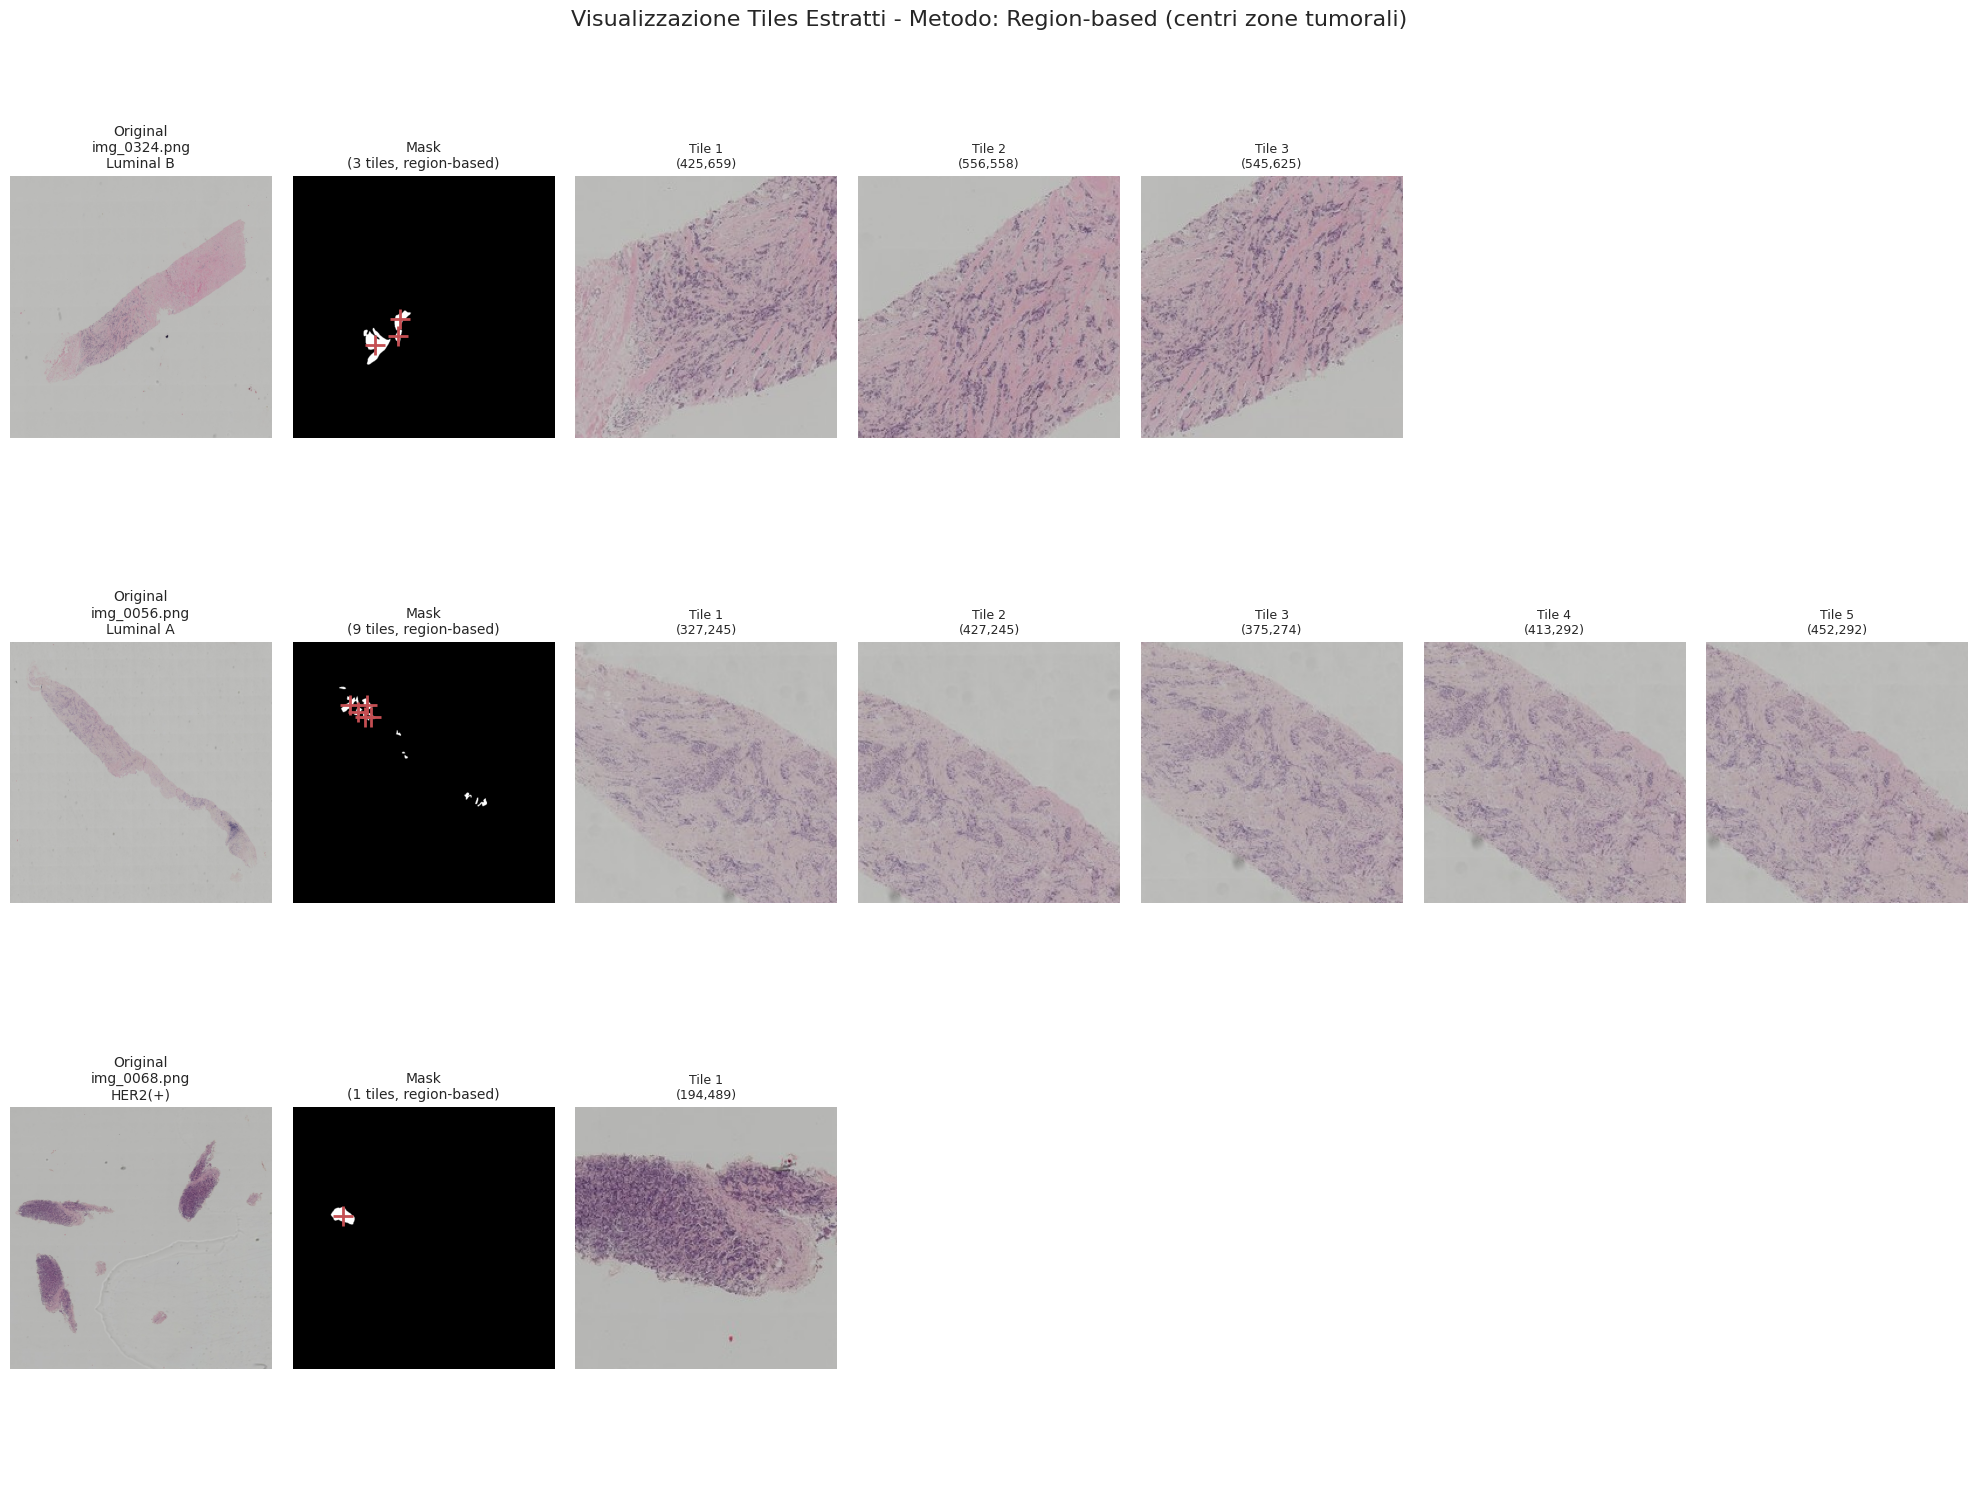

In [ ]:
from collections import defaultdict

train_tiles_per_patient = defaultdict(int)
for sample_filename in train_df_split['sample_index']:
    all_files = {}
    for root, _, files in os.walk(TRAIN_DATA_PATH):
        for f in files:
            all_files[f] = Path(root) / f
    
    image_path = all_files.get(sample_filename)
    if not image_path:
        continue
    
    try:
        img = cv2.imread(str(image_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if img is None:
            continue
        
        mask = None
        if USE_MASK:
            sample_num = sample_filename.replace('img_', '').replace('.png', '')
            mask_filename = f'mask_{sample_num}.png'
            mask_path = all_files.get(mask_filename)
            if mask_path:
                mask = cv2.imread(str(mask_path), 0)
        
        if USE_MASK and mask is None:
            continue
            
        tiles, _, _ = extract_tiles_from_tumor_regions( 
            img, mask,
            tile_size=TILE_SIZE,
            min_region_area=500,
            max_tiles=MAX_TILES_PER_IMAGE
        )
        
        train_tiles_per_patient[sample_filename] = len(tiles)
    except Exception as e:
        continue

print("=" * 80)
print(f"📊 REPORT: Tiles Estratti per Immagine (Training Set)")
print(f"🎯 Metodo: Region-based (zone tumorali)")
print("=" * 80)
print(f"\nTotale immagini processate: {len(train_tiles_per_patient)}")
print(f"Totale tiles estratti: {sum(train_tiles_per_patient.values())}")
print(f"\nStatistiche distribuzione:")
tiles_counts = list(train_tiles_per_patient.values())
if tiles_counts:
    print(f"  - Media tiles/immagine: {np.mean(tiles_counts):.2f}")
    print(f"  - Mediana tiles/immagine: {np.median(tiles_counts):.0f}")
    print(f"  - Min tiles/immagine: {np.min(tiles_counts)}")
    print(f"  - Max tiles/immagine: {np.max(tiles_counts)}")
    
    zero_tiles = sum(1 for c in tiles_counts if c == 0)
    if zero_tiles > 0:
        print(f"  - ⚠️ Immagini con 0 tiles: {zero_tiles}")

print(f"\n📋 Distribuzione per classe:")
label_dict = dict(zip(train_df_split['sample_index'], train_df_split['label']))
for class_name in class_names:
    class_samples = [s for s in train_tiles_per_patient.keys() if label_dict.get(s) == class_name]
    class_tiles = [train_tiles_per_patient[s] for s in class_samples]
    if class_tiles:
        print(f"  {class_name}: {len(class_samples)} immagini, media {np.mean(class_tiles):.1f} tiles/img")

print(f"\n🔍 Esempi (prime 10 immagini):")
for i, (sample, num_tiles) in enumerate(list(train_tiles_per_patient.items())[:10]):
    label = label_dict.get(sample, 'Unknown')
    print(f"  {sample}: {num_tiles} tiles [{label}]")

print("=" * 80)

samples_with_tiles = [s for s, count in train_tiles_per_patient.items() if count > 0]
num_examples = min(3, len(samples_with_tiles))

if num_examples > 0:
    example_samples = np.random.choice(samples_with_tiles, size=num_examples, replace=False)
    
    fig = plt.figure(figsize=(20, 5 * num_examples))
    
    for idx, sample_filename in enumerate(example_samples):
        label = label_dict.get(sample_filename, 'Unknown')
        
        all_files = {}
        for root, _, files in os.walk(TRAIN_DATA_PATH):
            for f in files:
                all_files[f] = Path(root) / f
        
        image_path = all_files.get(sample_filename)
        img = cv2.imread(str(image_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        sample_num = sample_filename.replace('img_', '').replace('.png', '')
        mask_filename = f'mask_{sample_num}.png'
        mask_path = all_files.get(mask_filename)
        mask = cv2.imread(str(mask_path), 0) if mask_path else None
        
        tiles, _, centers = extract_tiles_from_tumor_regions(
            img, mask,
            tile_size=TILE_SIZE,
            min_region_area=500,
            max_tiles=MAX_TILES_PER_IMAGE
        )
        
        ax1 = plt.subplot(num_examples, 7, idx * 7 + 1)
        img_display = cv2.resize(img, (512, 512))
        ax1.imshow(img_display)
        ax1.set_title(f'Original\n{sample_filename}\n{label}', fontsize=10)
        ax1.axis('off')
        
        ax2 = plt.subplot(num_examples, 7, idx * 7 + 2)
        if mask is not None:
            mask_display = cv2.resize(mask, (512, 512))
            ax2.imshow(mask_display, cmap='gray')
            
            if centers is not None and len(centers) > 0:
                h_orig, w_orig = mask.shape
                scale_x = 512 / w_orig
                scale_y = 512 / h_orig
                for cx, cy in centers[:5]:
                    cx_scaled = cx * scale_x
                    cy_scaled = cy * scale_y
                    ax2.plot(cx_scaled, cy_scaled, 'r+', markersize=15, markeredgewidth=2)
            
            title = f'Mask\n({train_tiles_per_patient.get(sample_filename, 0)} tiles, region-based)'
            ax2.set_title(title, fontsize=10)
        else:
            ax2.text(0.5, 0.5, 'No Mask', ha='center', va='center')
            ax2.set_title('Mask', fontsize=10)
        ax2.axis('off')
        
        num_tiles_to_show = min(5, len(tiles))
        for tile_idx in range(5):
            ax = plt.subplot(num_examples, 7, idx * 7 + 3 + tile_idx)
            if tile_idx < num_tiles_to_show:
                ax.imshow(tiles[tile_idx])
                if centers and tile_idx < len(centers):
                    cx, cy = centers[tile_idx]
                    ax.set_title(f'Tile {tile_idx+1}\n({cx},{cy})', fontsize=9)
                else:
                    ax.set_title(f'Tile {tile_idx+1}', fontsize=9)
            ax.axis('off')
    
    plt.suptitle(f'Visualizzazione Tiles Estratti - Metodo: Region-based (centri zone tumorali)', fontsize=16, y=0.995)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Nessuna immagine con tiles da visualizzare!")

## Data Augmentation and Dataset

This section defines the augmentation pipeline and PyTorch datasets for training.

### 4-Channel Transformation (FourChannelTransform)
Handles the RGB + Mask input format:
- **Synchronized augmentation**: Geometric transforms (flips, rotations) applied identically to RGB and mask
- **Color jitter on RGB only**: Color changes don't affect the binary mask
- **ImageNet normalization**: Applied only to RGB channels; mask stays in [0,1]

### Dataset Classes
- `FourChannelDataset`: 4-channel (RGB + Mask) dataset with synchronized augmentation

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

class FourChannelTransform:
    def __init__(self, augment=False):
        self.augment = augment
        self.mean = torch.tensor(IMAGENET_MEAN)
        self.std = torch.tensor(IMAGENET_STD)
        
        self.color_jitter = transforms.ColorJitter(
            brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1
        )
        self.affine = transforms.RandomAffine(
            degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)
        )
        
    def __call__(self, x):
        rgb = x[:3]
        mask = x[3:4]
        
        if self.augment:
            if torch.rand(1) > 0.5:
                rgb = torch.flip(rgb, [-1])
                mask = torch.flip(mask, [-1])
            if torch.rand(1) > 0.5:
                rgb = torch.flip(rgb, [-2])
                mask = torch.flip(mask, [-2])
            
            k = torch.randint(0, 4, (1,)).item()
            if k > 0:
                rgb = torch.rot90(rgb, k, [-2, -1])
                mask = torch.rot90(mask, k, [-2, -1])
                
            rgb = self.color_jitter(rgb)

        for t, m, s in zip(rgb, self.mean, self.std):
            t.sub_(m).div_(s)
        
        return torch.cat([rgb, mask], dim=0)


class FourChannelDataset(Dataset):
    def __init__(self, data, labels, augment=False):
        self.data = torch.FloatTensor(data)
        self.labels = torch.LongTensor(labels)
        self.transform = FourChannelTransform(augment=augment)
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        image = self.data[idx].clone()
        label = self.labels[idx]
        image = self.transform(image)
        return image, label

val_transform_4ch = FourChannelTransform(augment=False)

print("✅ Data Augmentation configurata (ColorJitter + Rotazioni + Flips)")

train_ds = FourChannelDataset(X_train, y_train, augment=True)
val_ds = FourChannelDataset(X_val, y_val, augment=False)

print(f"✅ Data Augmentation configurata (4 canali, sincronizzata).")
print(f"Training samples: {len(train_ds)}")
print(f"Validation samples: {len(val_ds)}")

✅ Data Augmentation configurata (ColorJitter + Rotazioni + Flips)
✅ Data Augmentation configurata (4 canali, sincronizzata).
Training samples: 2925
Validation samples: 762


## Model Architecture - Parallel DenseNet (Dual-Stream)

A **dual-pathway architecture** that processes RGB and Mask information separately before fusion.

### Architecture Overview
```
Input (4 channels: RGB + Mask)
         │
    ┌────┴────┐
    │         │
    ▼         ▼
RGB Path   Mask Path
(EfficientNetV2-L)  (DenseNet121)
(Pretrained)   (From scratch)
    │         │
    ▼         ▼
RGB Features  Mask Features
(1280-dim)    (1024-dim)
    │         │
    └────┬────┘
         │
    Concatenation
    (2304-dim)
         │
         ▼
    Classifier
    (Dropout + Linear)
         │
         ▼
    4 Classes
```

### Key Design Choices
- **RGB pathway**: Uses pretrained EfficientNetV2-L (ImageNet weights) for rich feature extraction
- **Mask pathway**: DenseNet121 trained from scratch (mask has no ImageNet equivalent)
- **Late fusion**: Features are concatenated before the final classifier
- **Dropout (0.5)**: Regularization before the output layer

In [ ]:
import torch.nn as nn
import torchvision
from torch.nn.modules.flatten import Flatten

class SingleChannelDenseNet(nn.Module):
    def __init__(self, in_channels=1):
        super().__init__()
        self.backbone = torchvision.models.densenet121(weights=None) 

        original_conv = self.backbone.features.conv0
        new_conv = nn.Conv2d(
            in_channels=in_channels,
            out_channels=original_conv.out_channels,
            kernel_size=original_conv.kernel_size,
            stride=original_conv.stride,
            padding=original_conv.padding,
            bias=False
        )
        nn.init.kaiming_normal_(new_conv.weight, mode='fan_out', nonlinearity='relu')
        
        self.backbone.features.conv0 = new_conv

        in_features = self.backbone.classifier.in_features
        self.backbone.classifier = nn.Identity()
        self.output_features = in_features

    def forward(self, x):
        return self.backbone(x)

class ThreeChannelDenseNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = torchvision.models.efficientnet_v2_l(
            weights=torchvision.models.EfficientNet_V2_L_Weights.IMAGENET1K_V1
        )
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier[1] = nn.Identity()
        self.output_features = in_features

    def forward(self, x):
        return self.backbone(x)

class ParallelDenseNet(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.5):
        super().__init__()

        self.rgb_path = ThreeChannelDenseNet()
        self.mask_path = SingleChannelDenseNet(in_channels=1)

        fused_features_dim = self.rgb_path.output_features + self.mask_path.output_features
        
        self.fusion_classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(fused_features_dim, num_classes)
        )

    def forward(self, x_4ch):
        x_rgb = x_4ch[:, :3]
        x_mask = x_4ch[:, 3:4]

        rgb_features = self.rgb_path(x_rgb)
        mask_features = self.mask_path(x_mask)

        fused_features = torch.cat([rgb_features, mask_features], dim=1)
        
        output = self.fusion_classifier(fused_features)
        return output

print("✅ Modelli a Percorso Parallelo definiti.")

✅ Modelli a Percorso Parallelo definiti.


In [ ]:
model = ParallelDenseNet(num_classes, dropout_rate=0.5).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


Total parameters: 124,191,076
Trainable parameters: 124,191,076


## Focal Loss

Implementation of **Focal Loss** for handling class imbalance in the dataset.

### Formula
$$FL(p_t) = -\alpha_t \cdot (1 - p_t)^\gamma \cdot \log(p_t)$$

### Key Parameters
- **α (alpha)**: Per-class weighting factor (computed from class frequencies)
- **γ (gamma)**: Focusing parameter (default=2.0)
  - Higher γ → more focus on hard-to-classify examples
  - γ=0 reduces to standard cross-entropy

### Why Focal Loss?
- Standard cross-entropy treats all samples equally
- Focal Loss **down-weights easy examples** and focuses training on hard negatives
- Particularly effective for imbalanced medical imaging datasets

In [ ]:
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        p_t = torch.exp(-ce_loss)
        focal_loss = (1 - p_t) ** self.gamma * ce_loss
        
        if self.alpha is not None:
            if isinstance(self.alpha, (list, np.ndarray)):
                alpha_t = torch.tensor(self.alpha, device=inputs.device)[targets]
            else:
                alpha_t = self.alpha
            focal_loss = alpha_t * focal_loss
            
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

print("✅ Focal Loss implementata")

✅ Focal Loss implementata


## Training Setup

Configuration of all training components:

### Hyperparameters
| Parameter | Value | Description |
|-----------|-------|-------------|
| Batch Size | 32 | Samples per gradient update |
| Epochs | 80 | Maximum training iterations |
| Learning Rate | 2e-5 | Low LR for Lion optimizer |
| Patience | 10 | Early stopping threshold |
| Weight Decay | 1e-2 | L2 regularization |

### Components
- **Loss**: Focal Loss with balanced class weights (γ=2.0)
- **Optimizer**: Lion with weight decay
- **Scheduler**: Cosine Annealing (smooth LR decay to 1e-7)
- **Mixed Precision**: AMP (Automatic Mixed Precision) for faster GPU training

In [ ]:
BATCH_SIZE = 32
EPOCHS = 80
PATIENCE = 10
LEARNING_RATE = 2e-5

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, 
                         num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, 
                       num_workers=0, pin_memory=True)

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
criterion = FocalLoss(alpha=class_weights.tolist(), gamma=2.0, reduction='mean')

optimizer = Lion(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-2)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-7)

scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

print(f"\n📋 Training Configuration:")
print(f"Optimizer: Lion (LR: {LEARNING_RATE})")
print(f"Scheduler: CosineAnnealingLR (T_max: {EPOCHS})")
print(f"Loss: Focal Loss (gamma=2.0)")
print(f"Class weights: {class_weights}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Max epochs: {EPOCHS}")
print(f"Early stopping patience: {PATIENCE}")


📋 Training Configuration:
Optimizer: Lion (LR: 2e-05)
Scheduler: CosineAnnealingLR (T_max: 80)
Loss: Focal Loss (gamma=2.0)
Class weights: [2.69833948 0.92680608 0.68791157 0.91178304]
Batch size: 32
Max epochs: 80
Early stopping patience: 10


## Training Loop

The main training procedure with the following features:

### Per-Epoch Operations
1. **Training phase**: Forward pass, loss computation, backpropagation with AMP
2. **Validation phase**: Tile-level evaluation (fast feedback during training)
3. **Scheduler step**: Updates learning rate following cosine schedule
4. **Logging**: Prints loss and F1-score for both train and validation

### Training Functions
- `train_epoch()`: One pass through training data with gradient updates
- `validate_epoch()`: Tile-level validation (used during training)
- `validate_with_logits_aggregation()`: **Patient-level** validation using mean logits

### Early Stopping
- Monitors **validation F1-score**
- Saves best model checkpoint when F1 improves
- Stops training after 10 epochs without improvement

### Logits Aggregation (Patient-Level)
For final validation, tiles from the same patient are aggregated:
1. Get logits (pre-softmax outputs) for all tiles of a patient
2. Compute the **mean** of all logits
3. Take argmax of mean logits as final prediction

This approach is more robust than majority voting as it considers prediction confidence.

In [ ]:
def train_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_targets = []
    
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad(set_to_none=True)
        
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            outputs = model(inputs)
            loss = criterion(outputs, targets)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item() * inputs.size(0)
        preds = outputs.argmax(dim=1)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(targets.cpu().numpy())
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_f1 = f1_score(np.concatenate(all_targets), np.concatenate(all_preds), average='weighted')
    
    return epoch_loss, epoch_f1


def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            
            running_loss += loss.item() * inputs.size(0)
            preds = outputs.argmax(dim=1)
            all_preds.append(preds.cpu().numpy())
            all_targets.append(targets.cpu().numpy())
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_f1 = f1_score(np.concatenate(all_targets), np.concatenate(all_preds), average='weighted')
    
    return epoch_loss, epoch_f1


def validate_with_logits_aggregation(model, patient_tiles, transform, device, batch_size=32):
    model.eval()
    all_preds = []
    all_targets = []
    
    for sample_index, data in tqdm(patient_tiles.items(), desc="Validating with logits aggregation"):
        tiles = data['tiles']
        label = data['label']
        
        if len(tiles) == 0:
            continue
        
        tiles_tensor = torch.stack([torch.FloatTensor(tile) for tile in tiles])
        
        if transform:
            tiles_tensor = torch.stack([transform(tile) for tile in tiles_tensor])
        
        all_logits = []
        for i in range(0, len(tiles_tensor), batch_size):
            batch = tiles_tensor[i:i+batch_size].to(device)
            
            with torch.no_grad():
                with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                    outputs = model(batch)
                    all_logits.append(outputs.cpu())
        
        all_logits = torch.cat(all_logits, dim=0)
        
        mean_logits = all_logits.mean(dim=0)
        
        predicted_class = mean_logits.argmax().item()
        all_preds.append(predicted_class)
        all_targets.append(label)
    
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    
    accuracy = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average='weighted')
    
    return accuracy, f1, all_preds, all_targets


history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
best_f1 = 0
patience_counter = 0

print("\n🚀 Inizio Training...\n")
for epoch in range(1, EPOCHS + 1):
    train_loss, train_f1 = train_epoch(model, train_loader, criterion, optimizer, scaler, device)
    val_loss, val_f1 = validate_epoch(model, val_loader, criterion, device)
    
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)
    
    print(f"Epoch {epoch:2d}/{EPOCHS} | LR: {current_lr:.2e} | "
          f"Train: Loss={train_loss:.4f}, F1={train_f1:.4f} | "
          f"Val: Loss={val_loss:.4f}, F1={val_f1:.4f}")
    
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), 'models/best_model.pt')
        patience_counter = 0
        print(f"  ⭐ Best model saved! (F1={val_f1:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n⏹️ Early stopping at epoch {epoch}")
            break

model.load_state_dict(torch.load('models/best_model.pt'))
print(f"\n✅ Training completato!")
print(f"Best validation F1-score: {best_f1:.4f} ({best_f1*100:.2f}%)")


🚀 Inizio Training...

Epoch  1/80 | LR: 2.00e-05 | Train: Loss=0.8985, F1=0.2805 | Val: Loss=0.8646, F1=0.2746
  ⭐ Best model saved! (F1=0.2746)
Epoch  2/80 | LR: 2.00e-05 | Train: Loss=0.7364, F1=0.3842 | Val: Loss=0.8794, F1=0.3373
  ⭐ Best model saved! (F1=0.3373)
Epoch  3/80 | LR: 1.99e-05 | Train: Loss=0.6387, F1=0.4396 | Val: Loss=0.9063, F1=0.3237
Epoch  4/80 | LR: 1.99e-05 | Train: Loss=0.5510, F1=0.4954 | Val: Loss=1.0471, F1=0.3664
  ⭐ Best model saved! (F1=0.3664)
Epoch  5/80 | LR: 1.98e-05 | Train: Loss=0.4856, F1=0.5625 | Val: Loss=1.0129, F1=0.3775
  ⭐ Best model saved! (F1=0.3775)
Epoch  6/80 | LR: 1.97e-05 | Train: Loss=0.3982, F1=0.6380 | Val: Loss=1.0803, F1=0.3769
Epoch  7/80 | LR: 1.96e-05 | Train: Loss=0.3480, F1=0.6631 | Val: Loss=1.3429, F1=0.3754
Epoch  8/80 | LR: 1.95e-05 | Train: Loss=0.2985, F1=0.7166 | Val: Loss=1.4026, F1=0.3870
  ⭐ Best model saved! (F1=0.3870)
Epoch 10/80 | LR: 1.92e-05 | Train: Loss=0.2351, F1=0.7603 | Val: Loss=1.4977, F1=0.3775
Epoch 

## Evaluation and Visualization

Post-training analysis and results visualization:

### Training History Plots
- **Loss curves**: Train vs. Validation loss over epochs (monitors overfitting)
- **F1 curves**: Train vs. Validation F1-score progression

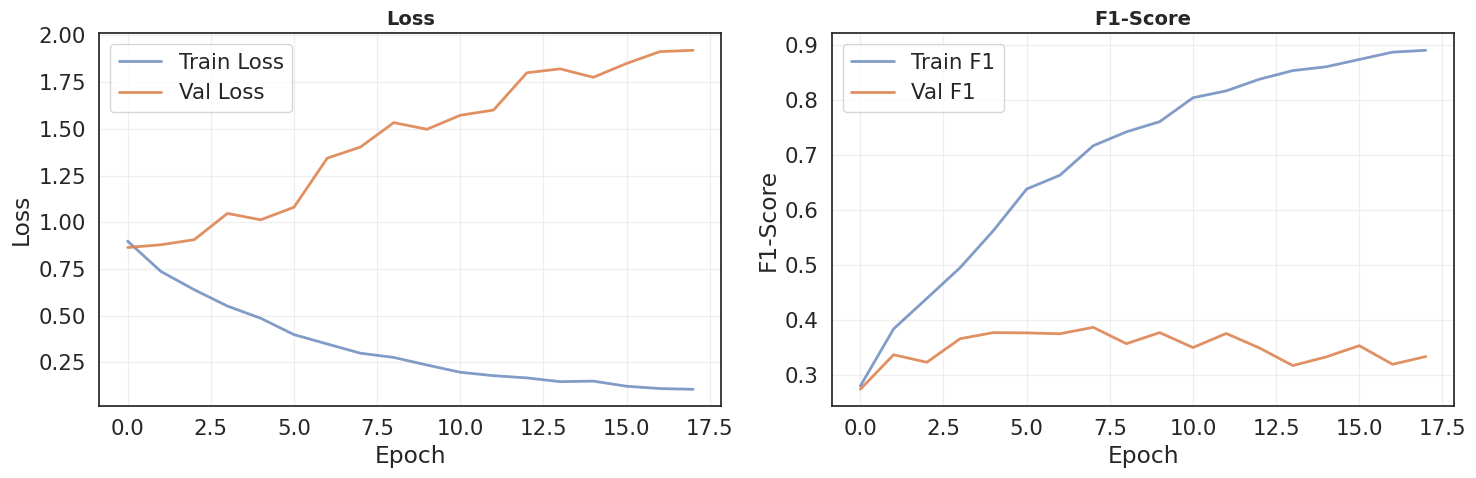

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history['train_loss'], label='Train Loss', alpha=0.7, linewidth=2)
ax1.plot(history['val_loss'], label='Val Loss', alpha=0.9, linewidth=2)
ax1.set_title('Loss', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history['train_f1'], label='Train F1', alpha=0.7, linewidth=2)
ax2.plot(history['val_f1'], label='Val F1', alpha=0.9, linewidth=2)
ax2.set_title('F1-Score', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('F1-Score')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


🔍 Validazione con Logits Aggregation...


Validating with logits aggregation: 100%|██████████| 117/117 [00:11<00:00,  9.76it/s]


📊 Validation Results:
Accuracy: 0.4530 (45.30%)
F1 Score: 0.4442

Classification Report:
                 precision    recall  f1-score   support

Triple negative       0.44      0.50      0.47        14
      Luminal A       0.48      0.38      0.42        32
      Luminal B       0.46      0.61      0.53        41
        HER2(+)       0.41      0.30      0.35        30

       accuracy                           0.45       117
      macro avg       0.45      0.45      0.44       117
   weighted avg       0.45      0.45      0.44       117



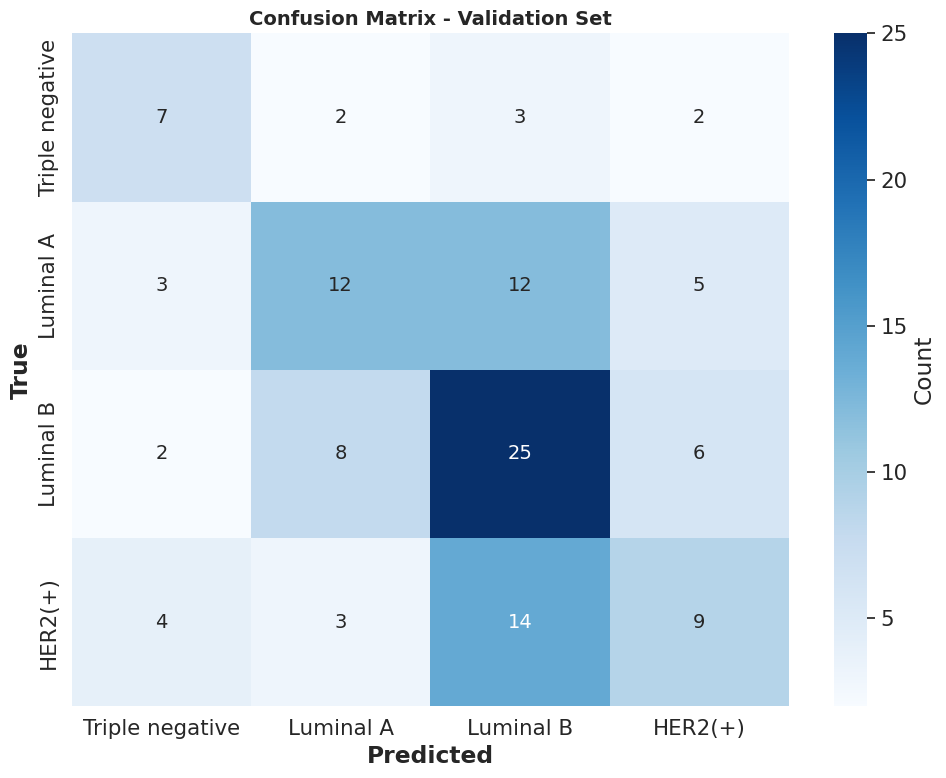

In [ ]:
print("\n🔍 Validazione con Logits Aggregation...")
val_acc, val_f1, val_preds, val_targets = validate_with_logits_aggregation(
    model,
    val_patient_tiles,
    val_transform_4ch,
    device,
    batch_size=BATCH_SIZE
)

print(f"📊 Validation Results:")
print(f"Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"F1 Score: {val_f1:.4f}\n")

print("Classification Report:")
print(classification_report(val_targets, val_preds, target_names=class_names))

cm = confusion_matrix(val_targets, val_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontweight='bold')
plt.ylabel('True', fontweight='bold')
plt.title('Confusion Matrix - Validation Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Test Predictions with Logits Aggregation

Final predictions on the test set using the same aggregation strategy as validation.

### Pipeline
1. **Tile extraction**: Extract 4-channel tiles from test images (region-based)
2. **Batch inference**: Process all tiles through the trained model
3. **Logits aggregation**: Mean of logits across all tiles per patient
4. **Final prediction**: Argmax of aggregated logits

### Functions
- `load_test_images_with_tiles()`: Extracts tiles from test images (4-channel, region-based)
- `predict_with_logits_aggregation()`: Generates predictions using mean logits

### Output
- **submission.csv**: Competition submission file with columns:
  - `sample_index`: Image filename
  - `label`: Predicted cancer subtype (string)

In [ ]:
def load_test_images_with_tiles(test_data_path, tile_size=224, use_mask=True, max_tiles=100):
    from collections import defaultdict
    
    image_tiles = defaultdict(list)
    
    all_paths = {}
    for root, _, files in os.walk(test_data_path):
        for f in files:
            all_paths[f] = os.path.join(root, f)

    image_files = sorted([f for f in all_paths.keys() 
                         if f.lower().startswith('img_') 
                         and f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    
    desc = "Loading test tiles (4-ch, region-based)"
    
    for filename in tqdm(image_files, desc=desc):
        filepath = all_paths[filename]
        
        try:
            img = cv2.imread(str(filepath))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            if img is None:
                continue
            
            h, w, _ = img.shape
            
            mask = None
            sample_num = filename.replace('img_', '').replace('.png', '')
            mask_filename = f'mask_{sample_num}.png'
            mask_path = all_paths.get(mask_filename)
            
            if mask_path:
                mask = cv2.imread(str(mask_path), 0)
            
            if mask is None:
                mask = np.zeros((h, w), dtype=np.uint8)
                
            tiles_rgb, tiles_mask, _ = extract_tiles_from_tumor_regions(
                img, mask,
                tile_size=tile_size,
                min_region_area=500,
                max_tiles=max_tiles
            )
            
            if len(tiles_rgb) == 0:
                img_resized = cv2.resize(img, (tile_size, tile_size))
                mask_resized = cv2.resize(mask, (tile_size, tile_size))
                
                tiles_rgb = [img_resized]
                tiles_mask = [mask_resized]
            
            for tile_rgb, tile_mask in zip(tiles_rgb, tiles_mask):
                t_rgb = tile_rgb.astype(np.float32) / 255.0
                t_rgb = np.transpose(t_rgb, (2, 0, 1))
                
                t_mask = tile_mask.astype(np.float32) / 255.0
                t_mask = np.expand_dims(t_mask, axis=0)
                
                tile_4ch = np.concatenate([t_rgb, t_mask], axis=0)
                image_tiles[filename].append(tile_4ch)
            
        except Exception as e:
            continue
    
    return image_tiles


def predict_with_logits_aggregation(model, image_tiles, transform, device, batch_size=32):
    model.eval()
    predictions = {}
    
    for filename, tiles in tqdm(image_tiles.items(), desc="Predicting with logits aggregation"):
        tiles_tensor = torch.stack([torch.FloatTensor(tile) for tile in tiles])
        
        if transform:
            tiles_tensor = torch.stack([transform(tile) for tile in tiles_tensor])
        
        all_logits = []
        for i in range(0, len(tiles_tensor), batch_size):
            batch = tiles_tensor[i:i+batch_size].to(device)
            
            with torch.no_grad():
                with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                    outputs = model(batch)
                    all_logits.append(outputs.cpu())
        
        all_logits = torch.cat(all_logits, dim=0)
        mean_logits = all_logits.mean(dim=0)
        
        predicted_class = mean_logits.argmax().item()
        predictions[filename] = predicted_class
    
    return predictions


print("\n🔍 Estrazione tiles da immagini test (4 Canali)...")
print(f"🎯 Metodo: Region-based (zone tumorali)")

test_transform_4ch = FourChannelTransform(augment=False) 

test_image_tiles = load_test_images_with_tiles(
    TEST_DATA_PATH,
    tile_size=TILE_SIZE,
    use_mask=USE_MASK,
    max_tiles=100
)

print(f"\nTest images loaded: {len(test_image_tiles)}")

if len(test_image_tiles) > 0:
    avg_tiles = np.mean([len(tiles) for tiles in test_image_tiles.values()])
    min_tiles = min([len(tiles) for tiles in test_image_tiles.values()])
    max_tiles = max([len(tiles) for tiles in test_image_tiles.values()])
    print(f"Tiles per image - Avg: {avg_tiles:.1f}, Min: {min_tiles}, Max: {max_tiles}")

    predictions_dict = predict_with_logits_aggregation(
        model, 
        test_image_tiles, 
        test_transform_4ch, 
        device,
        batch_size=BATCH_SIZE
    )

    filenames_test = sorted(predictions_dict.keys())
    all_predictions = [predictions_dict[f] for f in filenames_test]

    inverse_label_mapping = {v: k for k, v in label_mapping.items()}

submission_df = pd.DataFrame({
    'sample_index': filenames_test,
    'label': [inverse_label_mapping[pred] for pred in all_predictions]
})

submission_path = 'submission.csv'
submission_df.to_csv(submission_path, index=False)

print(f"\n✅ Submission Created!")
print(f"File: {submission_path}")
print(f"Total predictions: {len(submission_df)}")
print(f"\nPrediction distribution:")
print(submission_df['label'].value_counts())
print(f"\nFirst 10 rows:")
print(submission_df.head(10))


🔍 Estrazione tiles da immagini test (4 Canali)...
🎯 Metodo: Region-based (zone tumorali)


Loading test tiles (4-ch, region-based): 100%|██████████| 477/477 [00:28<00:00, 16.80it/s]



Test images loaded: 477
Tiles per image - Avg: 6.3, Min: 1, Max: 33


Predicting with logits aggregation: 100%|██████████| 477/477 [00:43<00:00, 11.07it/s]


✅ Submission Created!
File: submission.csv
Total predictions: 477

Prediction distribution:
label
Luminal B          205
Luminal A          109
HER2(+)             99
Triple negative     64
Name: count, dtype: int64

First 10 rows:
   sample_index            label
0  img_0000.png        Luminal B
1  img_0001.png        Luminal B
2  img_0002.png        Luminal B
3  img_0003.png  Triple negative
4  img_0004.png        Luminal B
5  img_0005.png          HER2(+)
6  img_0006.png  Triple negative
7  img_0007.png        Luminal B
8  img_0008.png        Luminal B
9  img_0009.png        Luminal B
